Enter classroom length (meters): 10
Enter classroom width (meters): 15
Enter classroom height (meters): 8
Enter initial router X position: 7
Enter initial router Y position: 14
Enter initial router Z position: 6

===== BEFORE OPTIMIZATION =====
Router Position: (7.0, 14.0, 6.0)
Total Signal Energy: 3656.09
Average Signal Strength: 3.05
Dead Zone Volume: 1047.62 cubic meters

===== AFTER OPTIMIZATION =====
Best Router Position (Mathematically Optimal): (5.0, 7.5, 4.0)
Total Signal Energy: 6107.42
Average Signal Strength: 5.09
Dead Zone Volume: 854.5 cubic meters


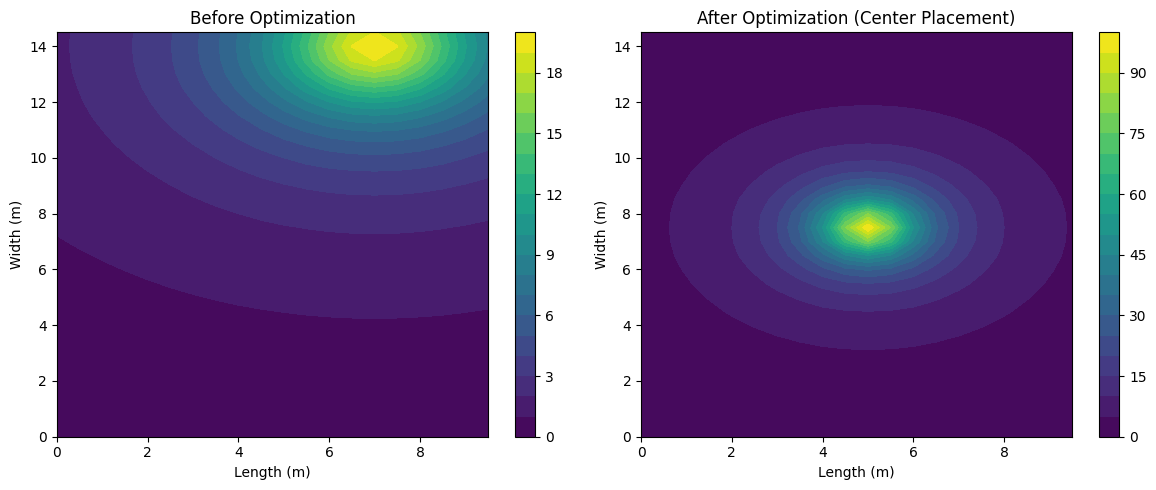

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# USER INPUT SECTION
# -----------------------------
length = float(input("Enter classroom length (meters): "))
width = float(input("Enter classroom width (meters): "))
height = float(input("Enter classroom height (meters): "))

router_x = float(input("Enter initial router X position: "))
router_y = float(input("Enter initial router Y position: "))
router_z = float(input("Enter initial router Z position: "))

power = 100
threshold = 5

dx = dy = dz = 0.5

x = np.arange(0, length, dx)
y = np.arange(0, width, dy)
z = np.arange(0, height, dz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

dV = dx * dy * dz
room_volume = length * width * height

# -----------------------------
# SIGNAL FUNCTION
# -----------------------------
def compute_signal(rx, ry, rz):
    S = power / (
        (X - rx)**2 +
        (Y - ry)**2 +
        (Z - rz)**2 + 1
    )
    total_signal = np.sum(S) * dV
    average_signal = total_signal / room_volume
    dead_zone = np.sum(S < threshold) * dV
    return S, total_signal, average_signal, dead_zone

# -----------------------------
# BEFORE OPTIMIZATION
# -----------------------------
S_before, total_before, avg_before, dead_before = compute_signal(router_x, router_y, router_z)

# -----------------------------
# FIND BEST ROUTER POSITION
# (Geometric Center Method)
# -----------------------------
best_rx = length / 2
best_ry = width / 2
best_rz = height / 2

S_after, total_after, avg_after, dead_after = compute_signal(best_rx, best_ry, best_rz)

# -----------------------------
# PRINT RESULTS
# -----------------------------
print("\n===== BEFORE OPTIMIZATION =====")
print("Router Position:", (router_x, router_y, router_z))
print("Total Signal Energy:", round(total_before, 2))
print("Average Signal Strength:", round(avg_before, 2))
print("Dead Zone Volume:", round(dead_before, 2), "cubic meters")

print("\n===== AFTER OPTIMIZATION =====")
print("Best Router Position (Mathematically Optimal):",
      (round(best_rx,2), round(best_ry,2), round(best_rz,2)))
print("Total Signal Energy:", round(total_after, 2))
print("Average Signal Strength:", round(avg_after, 2))
print("Dead Zone Volume:", round(dead_after, 2), "cubic meters")

# -----------------------------
# VISUALIZATION
# -----------------------------
mid_index = len(z) // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.contourf(X[:, :, mid_index],
             Y[:, :, mid_index],
             S_before[:, :, mid_index],
             levels=20)
plt.title("Before Optimization")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")
plt.colorbar()

plt.subplot(1,2,2)
plt.contourf(X[:, :, mid_index],
             Y[:, :, mid_index],
             S_after[:, :, mid_index],
             levels=20)
plt.title("After Optimization (Center Placement)")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")
plt.colorbar()

plt.tight_layout()
plt.show()